In [1]:
import os
import pandas as pd
import pymongo
import matplotlib.pyplot as plt
import seaborn as sns
import base64
from io import BytesIO
from PIL import Image
import numpy as np

In [2]:
# Verbindung zur Datenbank herstellen und Daten laden
def load_data():
    # Verbindung zur Datenbank herstellen
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()

    # Daten aus der 'canvassamples'-Collection laden
    canvassamples_collection = db['canvassamples']
    canvassamples_cursor = canvassamples_collection.find()
    canvassamples_data = list(canvassamples_cursor)
    canvassamples_df = pd.DataFrame(canvassamples_data)

    # Daten aus der 'fingerprints'-Collection laden
    fingerprints_collection = db['fingerprints']
    fingerprints_cursor = fingerprints_collection.find()
    fingerprints_data = list(fingerprints_cursor)
    fingerprints_df = pd.DataFrame(fingerprints_data)

    return canvassamples_df, fingerprints_df

# Daten laden
canvassamples_df, fingerprints_df = load_data()

In [3]:
# Anzeigen der ersten 5 Zeilen des DataFrames canvassamples_df
print("Erste 5 Zeilen des DataFrames canvassamples_df:")
display(canvassamples_df.head())

# Anzeigen der ersten 5 Zeilen des DataFrames fingerprints_df
print("Erste 5 Zeilen des DataFrames fingerprints_df:")
display(fingerprints_df)

Erste 5 Zeilen des DataFrames canvassamples_df:


,_id,fingerprintId,sampleData,createdAt,__v
0,66e326e9fab6918841db55db,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.847,0
1,66e326e9fab6918841db55df,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.906,0
2,66e326e9fab6918841db55d6,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.772,0
3,66e326e9fab6918841db55e3,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.981,0
4,66e326eafab6918841db55e7,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:46.049,0


Erste 5 Zeilen des DataFrames fingerprints_df:


,_id,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt,__v
0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
1,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
2,6704027b9717b7a0d17f219a,"{""UserAgent"":""Mozilla/5.0 (Linux; Android 10; ...",3136a4e8ed34934d00c2532b7f51066763fbbd8e13f3ef...,benutzername_4,Benutzer 4,Motorola 60,Android 11,100000,2024-10-07 15:47:07.157,0
3,670418779717b7a0d18c7e44,"{""UserAgent"":""Mozilla/5.0 (Linux; Android 10; ...",8976859842e60b401714b35ab0e6b68e0002076ca0571e...,benutzername_6,Benutzer 6,S24 Samsung,Android 14,100000,2024-10-07 17:20:55.198,0
4,670405759717b7a0d181cc3f,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",dca4a9bb1c2f6a6238fd0ad29e2c2d6567b1bbf1e0447f...,benutzername_5,Benutzer 5,iPhone 7,IOS 15.7,100000,2024-10-07 15:59:49.152,0
5,67041a8d9717b7a0d18d852a,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",c7b40c7a9a41fbb753dde543de4332252a4c0c433887df...,benutzername_7,Benutzer 7,iPhone SE,IOS 15.4.1,100000,2024-10-07 17:29:49.467,0
6,67041e029717b7a0d19070cc,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",705511461984cfdf5c9f3a279006f476dfda387f8de3e2...,benutzername_9,Benutzer 9,iPhone 5 SE,IOS 14.4.1,100000,2024-10-07 17:44:34.544,0
7,67041c899717b7a0d18f0c7f,"{""UserAgent"":""Mozilla/5.0 (Linux; Android 10; ...",8fe1f7c27e7c122659b6b6689fe84c498eb166c5a7259a...,benutzername_8,Benutzer 8,Tab S6 Lite,Android 13,100000,2024-10-07 17:38:17.666,0
8,670433cb9717b7a0d1a53a35,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",eaf6777c6565e57963d5df2ed27969c6102dc0233befc1...,benutzername_10,Benutzer 10,IPhone 8,IOS 14.4.1,100000,2024-10-07 19:17:31.972,0
9,6704362b9717b7a0d1a7876a,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",ee02f568b0c73b3326594fea0363b8d7171097ed5bf21f...,benutzername_11,Benutzer 11,Home Pc,Windows 11,100000,2024-10-07 19:27:39.666,0


In [4]:
# Daten zusammenführen
merged_df = pd.merge(canvassamples_df, fingerprints_df, left_on='fingerprintId', right_on='_id', suffixes=('_sample', '_fingerprint'))

# Benutzer-IDs extrahieren
user_ids = merged_df['username'].unique()

# DataFrames für jeden Benutzer erstellen
user_dfs = {user_id: merged_df[merged_df['username'] == user_id] for user_id in user_ids}

# Beispielhafte Anzeige der ersten 5 Zeilen für jeden Benutzer
for user_id, df in user_dfs.items():
    print(f"Erste 5 Zeilen für Benutzer {user_id}:")
    display(df.head())

Erste 5 Zeilen für Benutzer benutzername_1:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
0,66e326e9fab6918841db55db,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.847,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
1,66e326e9fab6918841db55df,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.906,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
2,66e326e9fab6918841db55d6,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.772,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
3,66e326e9fab6918841db55e3,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.981,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
4,66e326eafab6918841db55e7,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:46.049,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0


Erste 5 Zeilen für Benutzer benutzername_3:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
100000,6703f8369717b7a0d179d6e3,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.318,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100001,6703f8369717b7a0d179d6e7,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.339,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100002,6703f8369717b7a0d179d6eb,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.359,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100003,6703f8369717b7a0d179d6ef,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.379,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100004,6703f8369717b7a0d179d6f3,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.396,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0


Erste 5 Zeilen für Benutzer benutzername_4:


...

,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
1700000,6707bdebffc8085dd61d7c85,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.742,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700001,6707bdebffc8085dd61d7ca1,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.787,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700002,6707bdebffc8085dd61d7c8d,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.756,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700003,6707bdebffc8085dd61d7ca9,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.803,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700004,6707bdebffc8085dd61d7c99,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.773,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0


Erste 5 Zeilen für Benutzer benutzername_21:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
1800000,6707c487ffc8085dd625a040,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.494,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800001,6707c487ffc8085dd625a044,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.506,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800002,6707c487ffc8085dd625a048,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.517,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800003,6707c487ffc8085dd625a04c,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.528,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800004,6707c487ffc8085dd625a050,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.539,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0


Erste 5 Zeilen für Benutzer benutzername_22:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
1900000,6707cabdffc8085dd62a72c5,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.957,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900001,6707cabdffc8085dd62a72ca,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.964,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900002,6707cabdffc8085dd62a72d1,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.970,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900003,6707cabdffc8085dd62a72d8,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.976,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900004,6707cabdffc8085dd62a72dd,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.981,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0


/tmp/ipykernel_29/2912728279.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sampleData_length'] = df['sampleData'].apply(len)
/tmp/ipykernel_29/2912728279.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sampleData_length'] = df['sampleData'].apply(len)
/tmp/ipykernel_29/2912728279.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

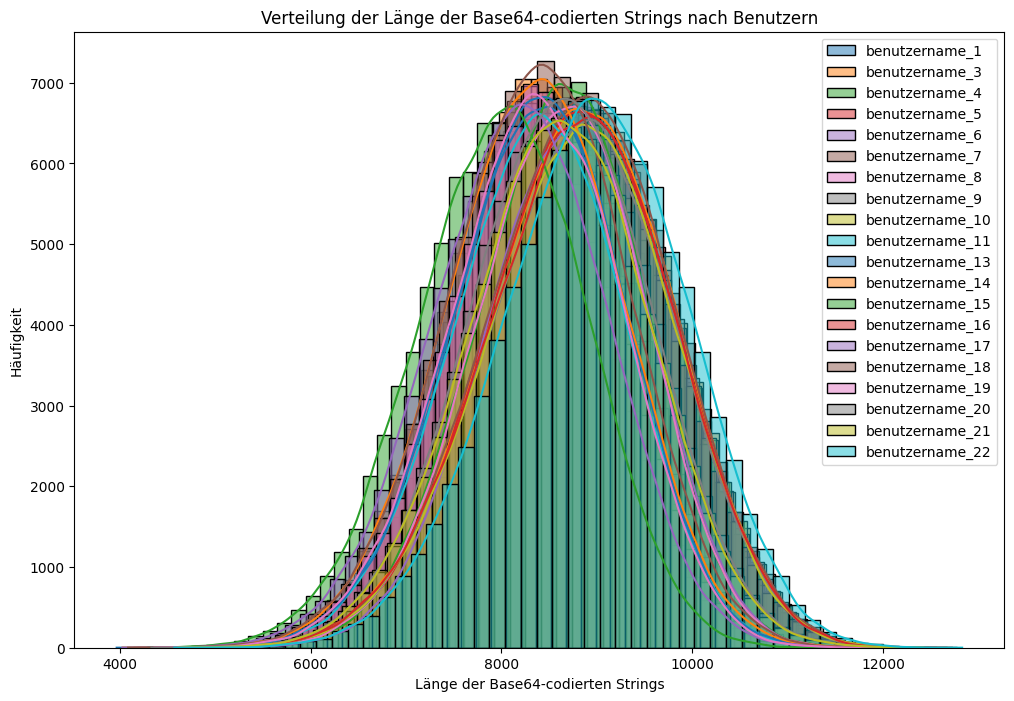

In [5]:
# Länge der Base64-codierten Strings analysieren
for user_id, df in user_dfs.items():
    df['sampleData_length'] = df['sampleData'].apply(len)

# Grafische Darstellung der Länge der Base64-codierten Strings nach Benutzern
plt.figure(figsize=(12, 8))
for user_id, df in user_dfs.items():
    sns.histplot(df['sampleData_length'], bins=50, kde=True, label=user_id)

plt.title('Verteilung der Länge der Base64-codierten Strings nach Benutzern')
plt.xlabel('Länge der Base64-codierten Strings')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

In [6]:
# Zusammenfassung der Ergebnisse
for user_id, df in user_dfs.items():
    summary = df['sampleData_length'].describe()
    print(f"Zusammenfassung der statistischen Analyse der Länge der Base64-codierten Strings für Benutzer {user_id}:")
    print(summary)

Zusammenfassung der statistischen Analyse der Länge der Base64-codierten Strings für Benutzer benutzername_1:
count    100000.000000
mean       8371.522080
std         898.778984
min        4408.000000
25%        7776.000000
50%        8396.000000
75%        8992.000000
max       12092.000000
Name: sampleData_length, dtype: float64
Zusammenfassung der statistischen Analyse der Länge der Base64-codierten Strings für Benutzer benutzername_3:
count    100000.000000
mean       8810.496360
std         976.081729
min        4156.000000
25%        8160.000000
50%        8832.000000
75%        9488.000000
max       12428.000000
Name: sampleData_length, dtype: float64
Zusammenfassung der statistischen Analyse der Länge der Base64-codierten Strings für Benutzer benutzername_4:
count    100000.000000
mean       8611.557640
std         872.015697
min        4444.000000
25%        8032.000000
50%        8636.000000
75%        9216.000000
max       12100.000000
Name: sampleData_length, dtype: float6

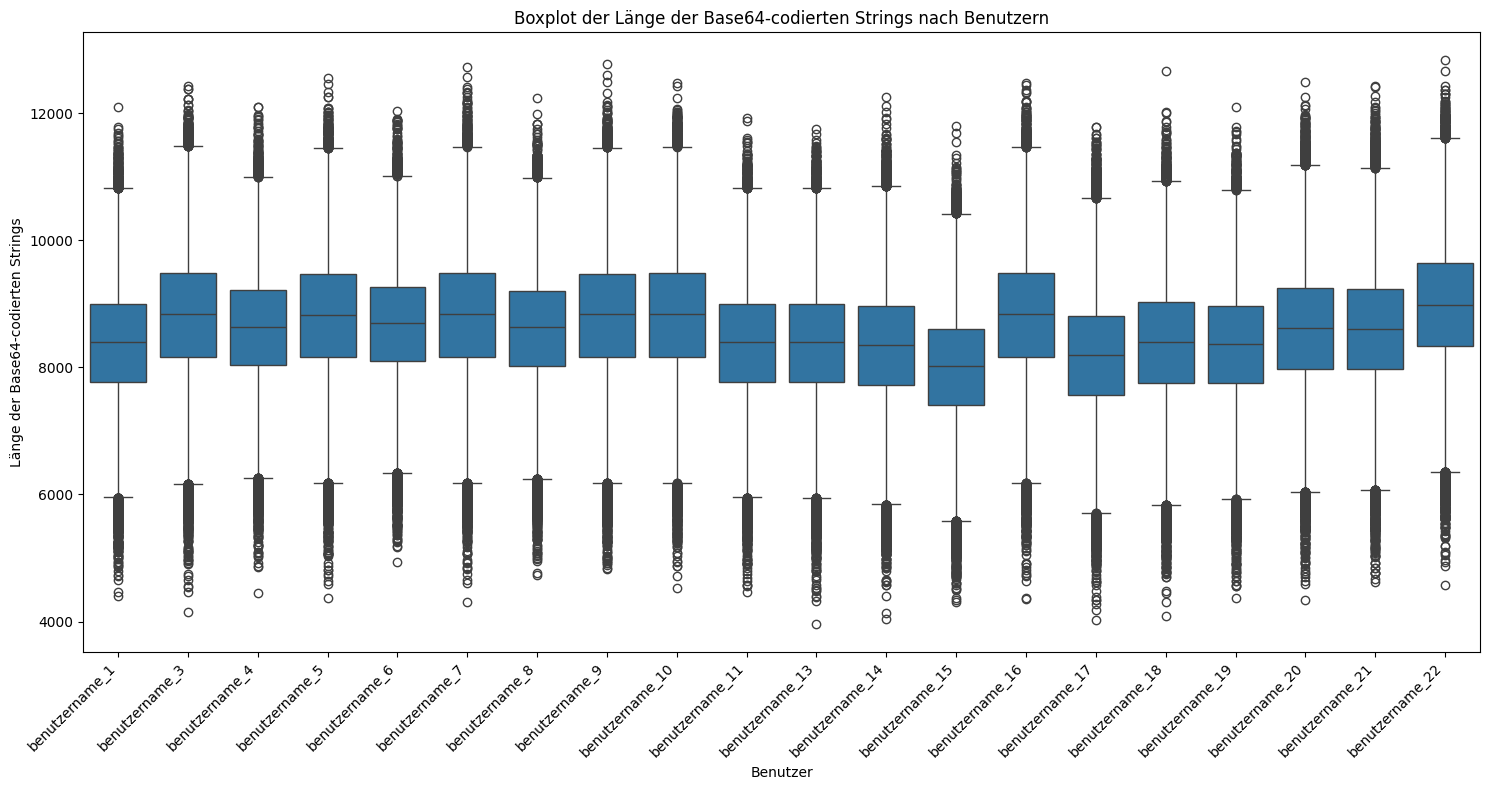

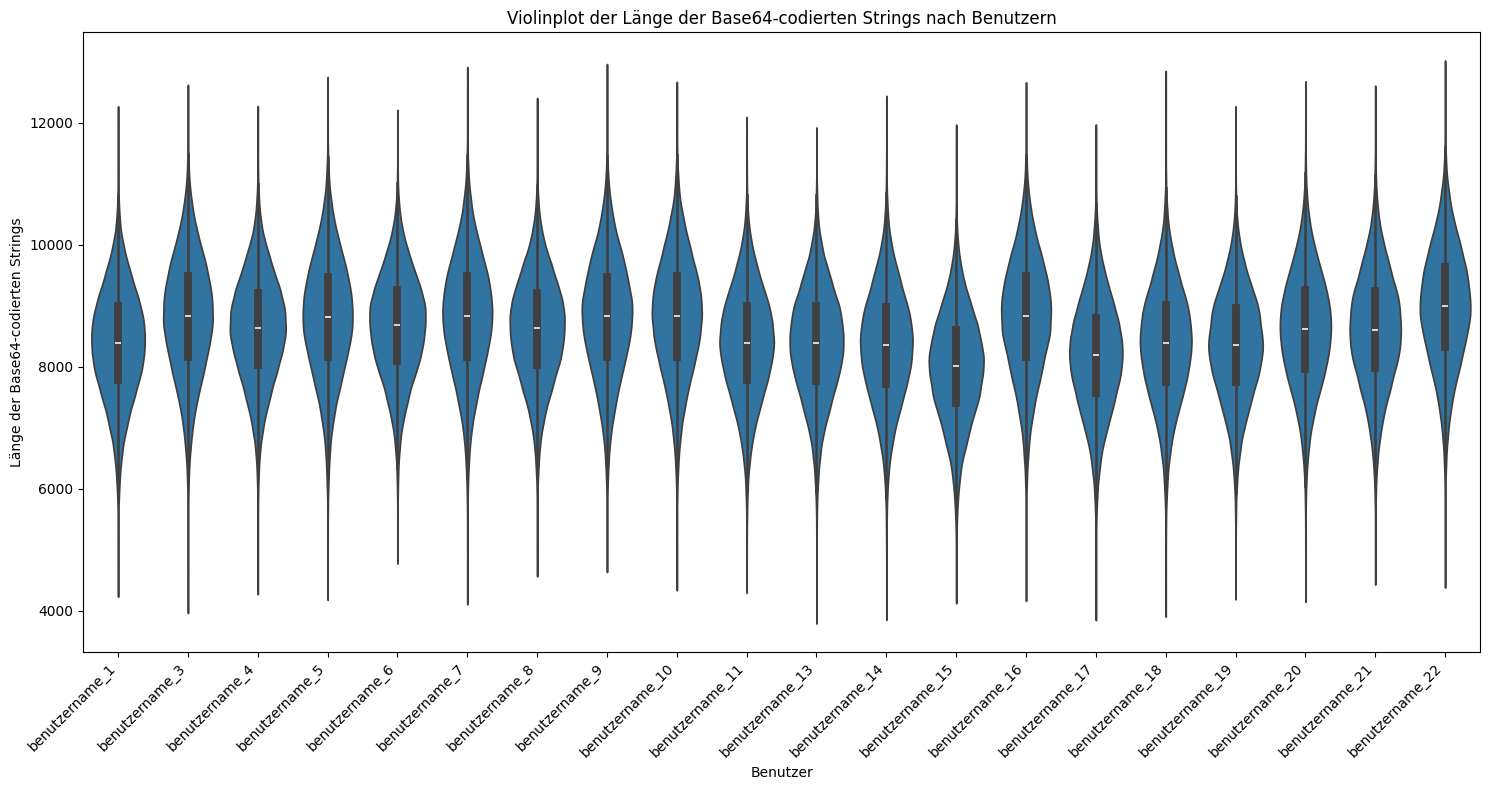

In [12]:
# Zusammenführen der Daten für die grafische Darstellung
lengths_df = pd.concat([df[['username', 'sampleData_length']] for df in user_dfs.values()])

# Boxplot der Länge der Base64-codierten Strings nach Benutzern
plt.figure(figsize=(15, 8))
sns.boxplot(x='username', y='sampleData_length', data=lengths_df)
plt.title('Boxplot der Länge der Base64-codierten Strings nach Benutzern')
plt.xlabel('Benutzer')
plt.ylabel('Länge der Base64-codierten Strings')
plt.xticks(rotation=45, ha='right')  # Rotate labels 45 degrees
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()

# Violinplot der Länge der Base64-codierten Strings nach Benutzern
plt.figure(figsize=(15, 8))
sns.violinplot(x='username', y='sampleData_length', data=lengths_df)
plt.title('Violinplot der Länge der Base64-codierten Strings nach Benutzern')
plt.xlabel('Benutzer')
plt.ylabel('Länge der Base64-codierten Strings')
plt.xticks(rotation=45, ha='right')  # Rotate labels 45 degrees
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()

In [8]:
# Zusammenfassung der Ergebnisse
for user_id, df in user_dfs.items():
    summary = df['sampleData_length'].describe()
    print(f"Zusammenfassung der statistischen Analyse der Länge der Base64-codierten Strings für Benutzer {user_id}:")
    print(summary)

Zusammenfassung der statistischen Analyse der Länge der Base64-codierten Strings für Benutzer benutzername_1:
count    100000.000000
mean       8371.522080
std         898.778984
min        4408.000000
25%        7776.000000
50%        8396.000000
75%        8992.000000
max       12092.000000
Name: sampleData_length, dtype: float64
Zusammenfassung der statistischen Analyse der Länge der Base64-codierten Strings für Benutzer benutzername_3:
count    100000.000000
mean       8810.496360
std         976.081729
min        4156.000000
25%        8160.000000
50%        8832.000000
75%        9488.000000
max       12428.000000
Name: sampleData_length, dtype: float64
Zusammenfassung der statistischen Analyse der Länge der Base64-codierten Strings für Benutzer benutzername_4:
count    100000.000000
mean       8611.557640
std         872.015697
min        4444.000000
25%        8032.000000
50%        8636.000000
75%        9216.000000
max       12100.000000
Name: sampleData_length, dtype: float6

In [9]:
# Install the required package
%pip install scikit-image

# Import the required function
from skimage.metrics import structural_similarity as ssim

# Assuming user1_images and user2_images are defined in CELL INDEX: 9
ssim_values = [calculate_ssim(user1_images[i], user2_images[i]) for i in range(min(len(user1_images), len(user2_images)))]

print("SSIM-Werte zwischen den ersten Bildern von Benutzer 1 und Benutzer 2:")
print(ssim_values)

     |████████████████████████████████| 13.9 MB 5.1 MB/s eta 0:00:01
     |████████████████████████████████| 315 kB 23.0 MB/s eta 0:00:01
     |████████████████████████████████| 220 kB 21.5 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


NameError: name 'user1_images' is not defined

In [10]:
# Funktion zum Dekodieren eines Base64-codierten Bildes
def decode_base64_image(base64_string):
    image_data = base64.b64decode(base64_string)
    image = Image.open(BytesIO(image_data)).convert('L')  # Konvertieren in Graustufen
    return np.array(image)

# Funktion zur Berechnung der SSIM zwischen zwei Bildern
def calculate_ssim(image1, image2):
    return ssim(image1, image2)

# Beispielhafte Berechnung der SSIM zwischen den ersten Bildern von Benutzer 1 und Benutzer 2
user1_images = [decode_base64_image(sample) for sample in user_dfs[user_ids[0]]['sampleData'].head()]
user2_images = [decode_base64_image(sample) for sample in user_dfs[user_ids[1]]['sampleData'].head()]

ssim_values = [calculate_ssim(user1_images[i], user2_images[i]) for i in range(min(len(user1_images), len(user2_images)))]

print("SSIM-Werte zwischen den ersten Bildern von Benutzer 1 und Benutzer 2:")
print(ssim_values)

SSIM-Werte zwischen den ersten Bildern von Benutzer 1 und Benutzer 2:
[0.6759804756517143, 0.633252431404624, 0.6830895994253127, 0.6343792816225516, 0.6077919333779614]


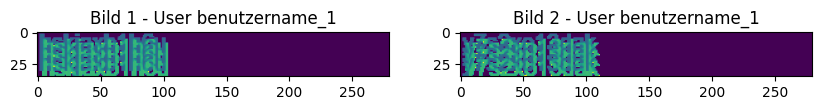

SSIM für gleichen Benutzer (benutzername_1): 0.6359031732374333

Vergleiche benutzername_1 mit benutzername_3
Bild 1 Shape: (35, 280)
Bild 2 Shape: (35, 280)
SSIM Wert: 0.6601597450043735

Vergleiche benutzername_1 mit benutzername_4
Bild 1 Shape: (35, 280)
Bild 2 Shape: (35, 280)
SSIM Wert: 0.6511807891391307

Vergleiche benutzername_1 mit benutzername_5
Bild 1 Shape: (35, 280)
Bild 2 Shape: (35, 280)
SSIM Wert: 0.6529380639021054

Vergleiche benutzername_1 mit benutzername_6
Bild 1 Shape: (35, 280)
Bild 2 Shape: (35, 280)
SSIM Wert: 0.6224503411383475

Vergleiche benutzername_1 mit benutzername_7
Bild 1 Shape: (35, 280)
Bild 2 Shape: (35, 280)
SSIM Wert: 0.6099129586125439

Vergleiche benutzername_1 mit benutzername_8
Bild 1 Shape: (35, 280)
Bild 2 Shape: (35, 280)
SSIM Wert: 0.6645384705461257

Vergleiche benutzername_1 mit benutzername_9
Bild 1 Shape: (35, 280)
Bild 2 Shape: (35, 280)
SSIM Wert: 0.6613617373412923

Vergleiche benutzername_1 mit benutzername_10
Bild 1 Shape: (35, 28

In [15]:
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

# Debug-Version der SSIM-Berechnung
def debug_ssim_calculation(user_dfs, user_ids):
    ssim_matrix = np.zeros((len(user_ids), len(user_ids)))
    
    # Test für gleichen Benutzer
    user_id = user_ids[0]
    images = [decode_base64_image(sample) for sample in user_dfs[user_id]['sampleData'].sample(n=2, random_state=42)]
    
    # Visualisiere Testbilder
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(images[0])
    plt.title(f'Bild 1 - User {user_id}')
    plt.subplot(1, 2, 2)
    plt.imshow(images[1])
    plt.title(f'Bild 2 - User {user_id}')
    plt.show()
    
    # Berechne SSIM für gleichen Benutzer
    test_ssim = ssim(images[0], images[1], multichannel=True)
    print(f"SSIM für gleichen Benutzer ({user_id}): {test_ssim}")
    
    # Normale SSIM-Matrix Berechnung mit Debugging
    for i, user_id1 in enumerate(user_ids):
        for j, user_id2 in enumerate(user_ids):
            if i != j:
                user1_images = [decode_base64_image(sample) for sample in user_dfs[user_id1]['sampleData'].sample(n=2, random_state=42)]
                user2_images = [decode_base64_image(sample) for sample in user_dfs[user_id2]['sampleData'].sample(n=2, random_state=42)]
                
                # Debug: Prüfe Bildformate
                print(f"\nVergleiche {user_id1} mit {user_id2}")
                print(f"Bild 1 Shape: {user1_images[0].shape}")
                print(f"Bild 2 Shape: {user2_images[0].shape}")
                
                ssim_values = [ssim(user1_images[k], user2_images[k], multichannel=True) 
                             for k in range(min(len(user1_images), len(user2_images)))]
                ssim_matrix[i, j] = np.mean(ssim_values)
                print(f"SSIM Wert: {ssim_matrix[i, j]}")
    
    return ssim_matrix

# Aufruf der Debug-Funktion
ssim_matrix = debug_ssim_calculation(user_dfs, user_ids)

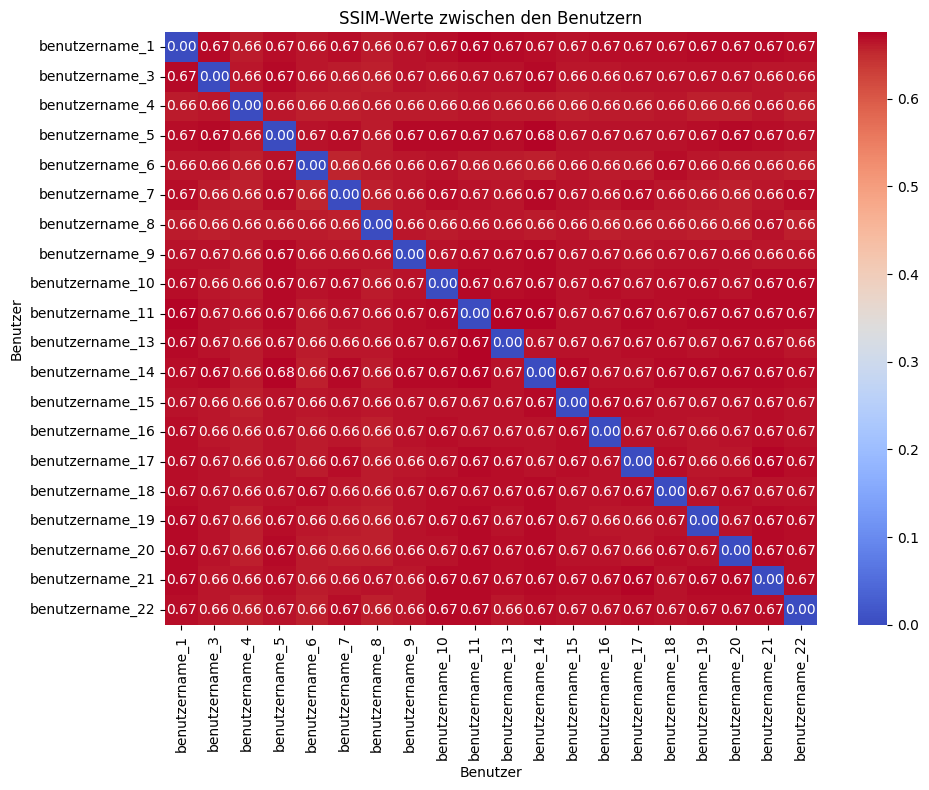

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# SSIM-Matrix berechnen
def calculate_ssim_matrix(user_dfs, user_ids):
    ssim_matrix = np.zeros((len(user_ids), len(user_ids)))
    
    for i, user_id1 in enumerate(user_ids):
        for j, user_id2 in enumerate(user_ids):
            if i != j:
                # Samples für beide Nutzer laden
                user1_images = [decode_base64_image(sample) for sample in user_dfs[user_id1]['sampleData'].sample(n=200, random_state=42)]
                user2_images = [decode_base64_image(sample) for sample in user_dfs[user_id2]['sampleData'].sample(n=200, random_state=42)]
                
                # SSIM für alle Bildpaare berechnen
                ssim_values = [ssim(user1_images[k], user2_images[k], multichannel=True) 
                             for k in range(min(len(user1_images), len(user2_images)))]
                ssim_matrix[i, j] = np.mean(ssim_values)
    
    return ssim_matrix

# Heatmap erstellen
def plot_ssim_heatmap(ssim_matrix, user_ids):
    plt.figure(figsize=(10, 8))
    sns.heatmap(ssim_matrix, 
                xticklabels=user_ids, 
                yticklabels=user_ids, 
                annot=True,        # Zeige Werte in den Zellen
                fmt='.2f',         # 2 Dezimalstellen
                cmap='coolwarm')   # Farbschema
    
    plt.title('SSIM-Werte zwischen den Benutzern')
    plt.xlabel('Benutzer')
    plt.ylabel('Benutzer')
    plt.tight_layout()
    plt.show()

# Verwendung
ssim_matrix = calculate_ssim_matrix(user_dfs, user_ids)
plot_ssim_heatmap(ssim_matrix, user_ids)

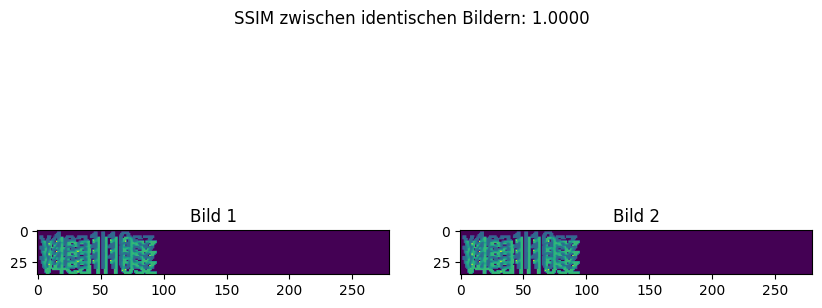

SSIM für identische Bilder: 1.0


In [19]:
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

# Ein einzelnes Sample laden und mit sich selbst vergleichen
def compare_same_fingerprint(user_dfs, user_id):
    # Ein Sample laden
    sample = user_dfs[user_id]['sampleData'].iloc[0]
    image = decode_base64_image(sample)
    
    # SSIM mit sich selbst berechnen
    ssim_value = ssim(image, image, multichannel=True)
    
    # Visualisierung
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title('Bild 1')
    plt.subplot(1, 2, 2)
    plt.imshow(image)
    plt.title('Bild 2')
    plt.suptitle(f'SSIM zwischen identischen Bildern: {ssim_value:.4f}')
    plt.show()
    
    return ssim_value

# Test mit erstem Benutzer
ssim_value = compare_same_fingerprint(user_dfs, user_ids[0])
print(f"SSIM für identische Bilder: {ssim_value}")

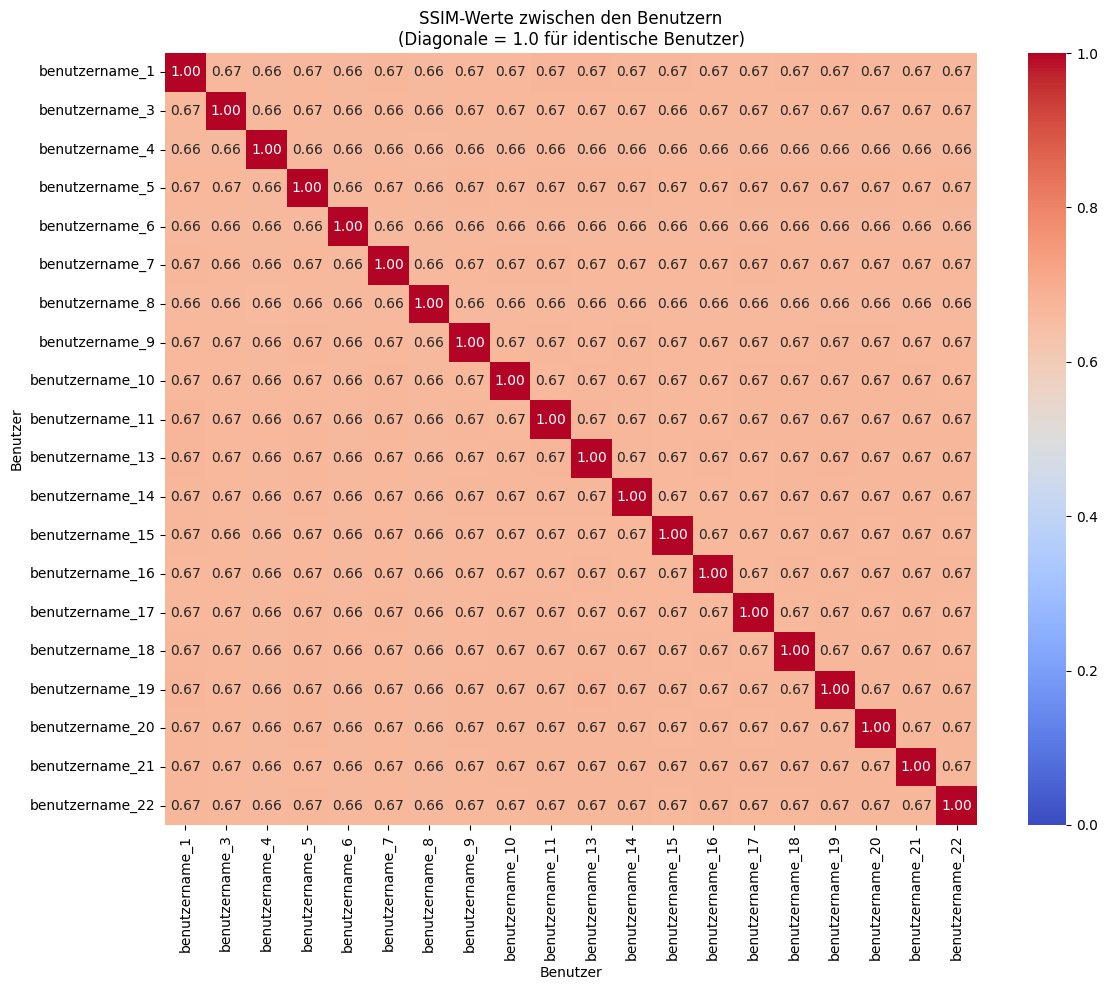

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

def calculate_ssim_matrix(user_dfs, user_ids):
    ssim_matrix = np.zeros((len(user_ids), len(user_ids)))
    
    for i, user_id1 in enumerate(user_ids):
        for j, user_id2 in enumerate(user_ids):
            if i == j:
                ssim_matrix[i,j] = 1.0
                continue
                
            user1_images = [decode_base64_image(sample) for sample in user_dfs[user_id1]['sampleData'].sample(n=2000, random_state=42)]
            user2_images = [decode_base64_image(sample) for sample in user_dfs[user_id2]['sampleData'].sample(n=2000, random_state=42)]
            
            ssim_values = [ssim(user1_images[k], user2_images[k], multichannel=True) 
                         for k in range(min(len(user1_images), len(user2_images)))]
            ssim_matrix[i, j] = np.mean(ssim_values)
    
    return ssim_matrix

# Heatmap mit verbesserter Formatierung
def plot_ssim_heatmap(ssim_matrix, user_ids):
    plt.figure(figsize=(12, 10))
    sns.heatmap(ssim_matrix, 
                xticklabels=user_ids, 
                yticklabels=user_ids, 
                annot=True,        
                fmt='.2f',         
                cmap='coolwarm',
                vmin=0,           # Minimum value for color scale
                vmax=1,           # Maximum value for color scale
                center=0.5)       # Center point for color scale
    
    plt.title('SSIM-Werte zwischen den Benutzern\n(Diagonale = 1.0 für identische Benutzer)')
    plt.xlabel('Benutzer')
    plt.ylabel('Benutzer')
    plt.tight_layout()
    plt.show()

# Verwendung
ssim_matrix = calculate_ssim_matrix(user_dfs, user_ids)
plot_ssim_heatmap(ssim_matrix, user_ids)

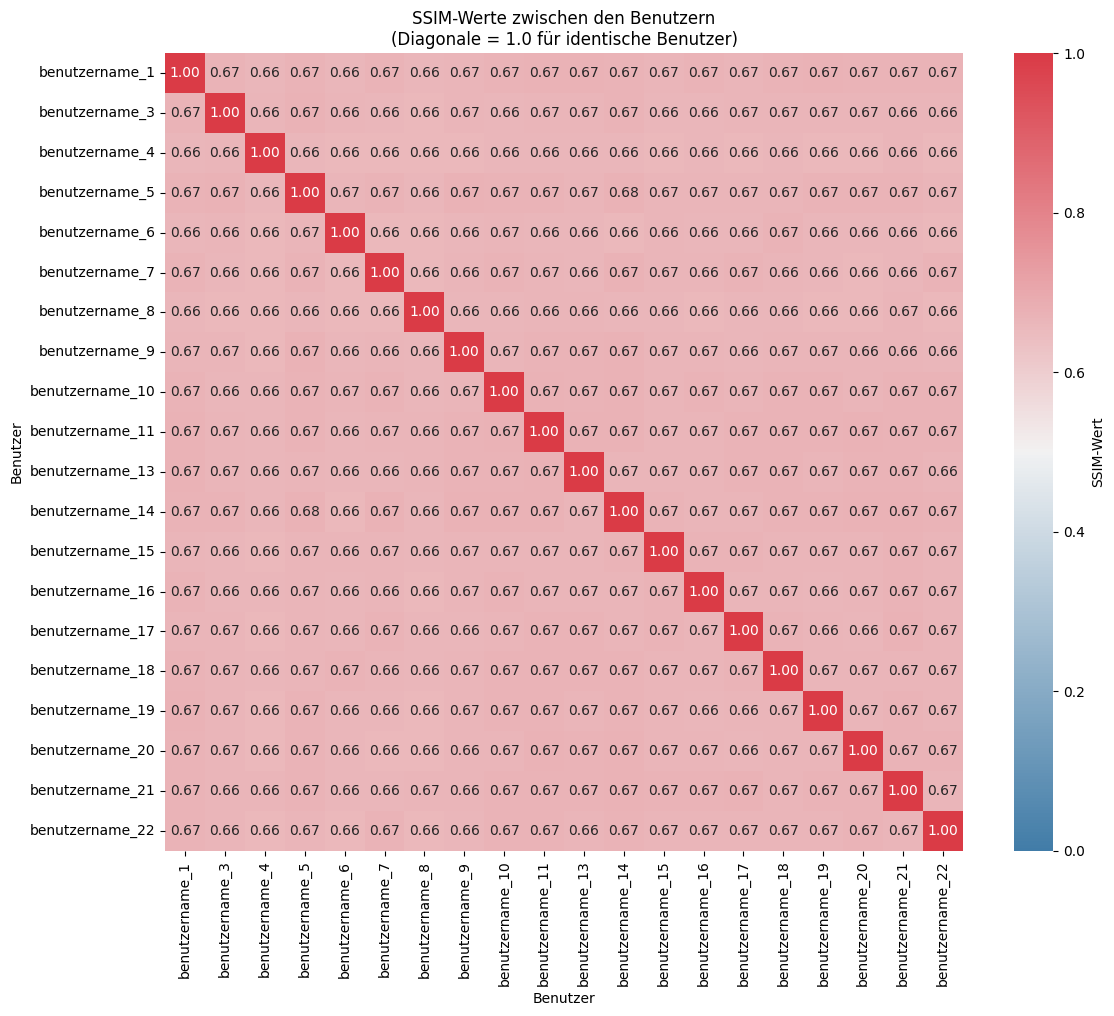

In [22]:
def plot_ssim_heatmap(ssim_matrix, user_ids):
    plt.figure(figsize=(12, 10))
    
    # Angepasstes Farbschema
    custom_cmap = sns.diverging_palette(240, 10, as_cmap=True)  # Blau zu Orange
    
    sns.heatmap(ssim_matrix, 
                xticklabels=user_ids, 
                yticklabels=user_ids, 
                annot=True,        
                fmt='.2f',         
                cmap=custom_cmap,  # Custom colormap
                vmin=0,           
                vmax=1,           
                center=0.5,
                square=True,       # Quadratische Zellen
                cbar_kws={'label': 'SSIM-Wert'})  # Colorbar Label
    
    plt.title('SSIM-Werte zwischen den Benutzern\n(Diagonale = 1.0 für identische Benutzer)')
    plt.xlabel('Benutzer')
    plt.ylabel('Benutzer')
    plt.tight_layout()
    plt.show()

# Verwendung bleibt gleich
ssim_matrix = calculate_ssim_matrix(user_dfs, user_ids)
plot_ssim_heatmap(ssim_matrix, user_ids)

In [ ]:
# Funktion zum Dekodieren und Anzeigen eines Base64-codierten Bildes
def display_base64_image(base64_string):
    image_data = base64.b64decode(base64_string)
    image = Image.open(BytesIO(image_data))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# Beispielhafte Anzeige der ersten 5 Canvas-Fingerprints für jeden Benutzer
for user_id, df in user_dfs.items():
    print(f"Canvas-Fingerprints für Benutzer {user_id}:")
    for i in range(min(5, len(df))):
        print(f"Canvas-Fingerprint {i+1}:")
        display_base64_image(df['sampleData'].iloc[i])

In [ ]:
# Zusammenfassung der Ergebnisse
for user_id, df in user_dfs.items():
    summary = df['sampleData_length'].describe()
    print(f"Zusammenfassung der statistischen Analyse der Länge der Base64-codierten Strings für Benutzer {user_id}:")
    print(summary)